# Etapa 3 — Modelagem

Entrada: `../data/processed/dataset.csv`, da Etapa 2.
Saída: um classificador treinado, avaliado e interpretado, e um ranking dos
melhores horários da janela.

Um detalhe que define esta etapa: **não existe label pronta.** O site
classifica as condições para pesca, não para surf — e pesca gosta de mar
calmo, quase o oposto. Definir o que é uma condição boa para surfar é a
primeira tarefa aqui, e é uma decisão sua.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

DIR_PROC = Path("..") / "data" / "processed"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Carregar o dataset processado

Confira que veio o que você espera: número de linhas, tipos, nulos. Se a
Etapa 2 mudou, isso aparece aqui.

In [2]:
dataset = pd.read_csv(DIR_PROC / "dataset.csv", parse_dates=["momento", "data"])
print(dataset.shape)
print("nulos:", int(dataset.isna().sum().sum()))
dataset.dtypes

(167, 16)
nulos: 0


momento           datetime64[us]
data              datetime64[us]
dia_semana                   str
hora                       int64
periodo                      str
de_dia                      bool
altura_m                 float64
altura_bruta_m           float64
direcao_onda                 str
vento_kmh                float64
direcao_vento                str
mare_altura_m            float64
mare_enchendo               bool
mare_fracao              float64
coeficiente                int64
idade_lua                  int64
dtype: object

In [3]:
dados = dataset[dataset["de_dia"]].reset_index(drop=True)
print(f"{len(dados)} horas de dia, de {len(dataset)}")
dados.head()

87 horas de dia, de 167


,momento,data,dia_semana,hora,periodo,de_dia,altura_m,altura_bruta_m,direcao_onda,vento_kmh,direcao_vento,mare_altura_m,mare_enchendo,mare_fracao,coeficiente,idade_lua
0,2026-10-01 06:00:00,2026-10-01,qui,6,manhã,True,1.2,0.9,E,25.0,E,2.24,True,0.966,64,19
1,2026-10-01 07:00:00,2026-10-01,qui,7,manhã,True,1.2,1.2,ESE,24.0,E,2.29,False,0.996,64,19
2,2026-10-01 08:00:00,2026-10-01,qui,8,manhã,True,1.2,1.2,E,23.0,E,2.13,False,0.901,64,19
3,2026-10-01 09:00:00,2026-10-01,qui,9,manhã,True,1.1,0.9,E,23.0,E,1.80,False,0.705,64,19
4,2026-10-01 10:00:00,2026-10-01,qui,10,manhã,True,1.1,1.1,E,21.0,E,1.37,False,0.455,64,19


**Só as horas de dia entram no modelo.** Não se surfa de madrugada, então
deixar as 80 horas noturnas só encheria a classe `ruim` de exemplos triviais e
inflaria qualquer métrica. O dataset da Etapa 2 continua com todas as horas,
e o filtro está aqui, visível.

## 2. Definir a label

Escreva, em código, a regra que separa condições ruins, boas e ótimas (ou
outro conjunto de classes, se preferir).

- Quais variáveis entram na regra: altura da onda, vento, maré, direção?
- Quais limiares? De onde vem o número — leitura, conversa com surfista,
  distribuição dos próprios dados? Registre a origem, mesmo que seja um chute
  informado.
- Como as classes ficaram distribuídas? Se 95% das horas caírem numa classe,
  a métrica do modelo vai mentir para você.

Documente a regra em markdown antes de seguir. Tudo depois disso depende dela.

### A regra

Duas variáveis entram na regra: **altura da onda** e **velocidade do vento**.
Cada uma vale pontos, e a soma vira a classe.

| Onda (m) | Pontos | | Vento (km/h) | Pontos |
|---|---|---|---|---|
| abaixo de 1,2 | 0 | | acima de 25 | 0 |
| 1,2 a menos de 1,5 | 1 | | acima de 20 até 25 | 1 |
| 1,5 ou mais | 2 | | acima de 15 até 20 | 2 |
| | | | até 15 | 3 |

**Nota = pontos da onda + pontos do vento.** `ruim` até 1, `boa` com 2,
`ótima` com 3 ou mais.

### De onde vem cada número

Isto é um **chute informado**, não uma medição, e a parte mais frágil do
projeto inteiro:

- **Limiares de onda (1,2 e 1,5 m):** olhei a distribuição dos próprios dados
  (as alturas de dia são 1,1 / 1,2 / 1,3 / 1,5 / 1,6 m, com um salto entre 1,3 e
  1,5) e usei a noção geral de que onda abaixo de ~1 m em praia aberta é
  pequena demais. Não foram checados com um surfista de João Pessoa.
- **Limiares de vento (15, 20 e 25 km/h):** aproximam a escala de Beaufort
  (brisa leve até ~19 km/h, moderada a partir de 20) e a regra prática de que
  vento do mar acima de ~20 km/h já "bagunça" a onda. Também não verificados.
- **O peso é igual** para onda e vento. É uma escolha, e dá para discordar:
  mudar o peso muda o ranking.

### O que ficou de fora e por quê

- **Direção do vento e da onda:** nesta janela o vento vem do mar em 100% das
  horas e a onda vem sempre de leste, então a direção não separa nenhuma hora
  de outra. Se aparecesse vento terral (da terra), valeria pontos extras, mas
  a regra não seria testada com isso.
- **Maré:** a EDA não achou relação entre maré e altura da onda, e o efeito
  dela no surf depende do fundo de cada pico, que não temos. Ela entra como
  *feature* do modelo, não da regra, de propósito: se o modelo der importância
  a ela, é sinal de que algo está errado.

### O que `ótima` significa aqui

Como o vento é maral a semana inteira, nenhuma hora é ótima de verdade para
surf. `ótima` quer dizer **o melhor que esta semana oferece**, e não "dia
perfeito".

In [4]:
def pontos_onda(altura):
    if altura < 1.2:
        return 0
    if altura < 1.5:
        return 1
    return 2


def pontos_vento(vento):
    if vento > 25:
        return 0
    if vento > 20:
        return 1
    if vento > 15:
        return 2
    return 3


def classificar(nota):
    if nota <= 1:
        return 0
    if nota == 2:
        return 1
    return 2


NOMES = ["ruim", "boa", "ótima"]

dados["nota_regra"] = dados["altura_m"].map(pontos_onda) + dados["vento_kmh"].map(pontos_vento)
dados["classe"] = dados["nota_regra"].map(classificar)
dados["dia"] = dados["momento"].dt.day

        horas     %
classe             
ruim       35  40.0
boa        38  44.0
ótima      14  16.0


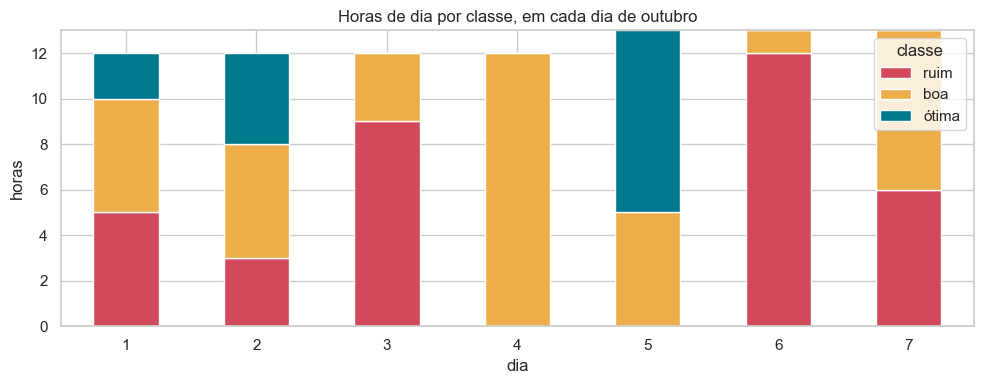

In [5]:
contagem = dados["classe"].map(dict(enumerate(NOMES))).value_counts().reindex(NOMES)
print(pd.DataFrame({"horas": contagem, "%": (contagem / len(dados) * 100).round(0)}))

fig, ax = plt.subplots(figsize=(10, 4))
por_dia = pd.crosstab(dados["dia"], dados["classe"]).rename(columns=dict(enumerate(NOMES)))
por_dia.plot.bar(stacked=True, ax=ax, color=["#d1495b", "#edae49", "#00798c"])
ax.set(title="Horas de dia por classe, em cada dia de outubro", xlabel="dia", ylabel="horas")
ax.legend(title="classe")
plt.xticks(rotation=0)
plt.tight_layout()

## 3. Features e alvo

Separe `X` e `y`.

- Quais colunas entram como feature? Cuidado: usar diretamente as variáveis da
  sua regra faz o modelo apenas redescobrir o `if` que você escreveu. Isso é
  esperado aqui — mas você precisa saber que é isso que está acontecendo.
- Direção do vento e da onda são texto. Como transformar em número sem inventar
  uma ordem que não existe?

In [6]:
colunas_numericas = ["altura_m", "vento_kmh", "mare_altura_m", "mare_fracao", "mare_enchendo", "hora"]
direcoes = pd.get_dummies(dados[["direcao_onda", "direcao_vento"]], dtype=int)

X = pd.concat([dados[colunas_numericas].astype(float), direcoes], axis=1)
y = dados["classe"]
grupos = dados["dia"]

print(X.shape)
print(list(X.columns))

(87, 12)
['altura_m', 'vento_kmh', 'mare_altura_m', 'mare_fracao', 'mare_enchendo', 'hora', 'direcao_onda_E', 'direcao_onda_ESE', 'direcao_onda_NE', 'direcao_vento_E', 'direcao_vento_ESE', 'direcao_vento_SE']


**O que entra.** `altura_m` e `vento_kmh` (as variáveis da regra, então o
modelo vai redescobrir o `if`: ver seção 7), a maré (altura, fração do caminho
e se está enchendo), a `hora` e as direções de onda e de vento.

**Direção como número sem inventar ordem.** Cada direção virou uma coluna 0/1
(`get_dummies`, ou *one-hot*). Se virassem 1, 2, 3 (E, ESE, SE), o modelo
trataria ESE como "meio caminho" entre E e SE e acharia SE duas vezes mais
longe de E do que ESE, e essa ordem é invenção nossa.

**O que ficou de fora e por quê.**
- `coeficiente` e `idade_lua`: são constantes dentro de cada dia. Com 7 dias,
  só serviriam para o modelo reconhecer o dia e decorar a classe dele.
- `altura_bruta_m`: é a mesma onda antes do tratamento da Etapa 2.
- `momento`, `data`, `dia_semana`, `periodo`: identificam o dia ou repetem a `hora`.

## 4. Treino e teste

Divida os dados. Vale estratificar pelas classes? A ordem temporal importa —
sortear linhas de um mesmo dia entre treino e teste vaza informação?

In [7]:
treino = dados["dia"] <= 5
teste = ~treino

X_treino, y_treino = X[treino], y[treino]
X_teste, y_teste = X[teste], y[teste]

print(pd.DataFrame({
    "treino (01–05/10)": y_treino.map(dict(enumerate(NOMES))).value_counts().reindex(NOMES),
    "teste (06–07/10)": y_teste.map(dict(enumerate(NOMES))).value_counts().reindex(NOMES),
}).fillna(0).astype(int))

        treino (01–05/10)  teste (06–07/10)
classe                                     
ruim                   17                18
boa                    30                 8
ótima                  14                 0


**A divisão é por dia, não por linha.** Treino em 01–05/10 e teste em 06–07/10:
o passado prevê o futuro. Horas vizinhas são quase idênticas (a onda das 13h e
a das 14h são a mesma, e o vento muda 1 ou 2 km/h), então sortear linhas
deixaria o modelo "colar" da hora ao lado. A seção 6 mede o quanto isso
infla o resultado.

**Estratificar não dá** quando se separa por dia: as classes ficam como o
calendário deixar, e o teste ficou sem nenhuma hora `ótima` (18 `ruim` e 8
`boa`). Por isso uso também validação cruzada deixando **um dia inteiro de
fora** a cada rodada (7 rodadas), que usa todos os dias como teste uma vez.

## 5. Treinar

Treine pelo menos dois modelos de famílias diferentes (por exemplo uma árvore
e um modelo baseado em distância) para ter com o que comparar.

In [8]:
modelos = {
    "árvore (profundidade 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    "KNN (k=5, padronizado)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "baseline (sempre a classe mais comum)": DummyClassifier(strategy="most_frequent"),
}

for modelo in modelos.values():
    modelo.fit(X_treino, y_treino)

In [9]:
profundidades = {"2": 2, "3": 3, "4": 4, "5": 5, "sem limite": None}
pd.Series({
    nome: accuracy_score(y, cross_val_predict(DecisionTreeClassifier(max_depth=p, random_state=0), X, y, groups=grupos, cv=LeaveOneGroupOut()))
    for nome, p in profundidades.items()
}, name="acurácia (um dia fora)").rename_axis("profundidade").round(2)

profundidade
2             0.56
3             0.46
4             0.60
5             0.67
sem limite    0.69
Name: acurácia (um dia fora), dtype: float64

**Os dois modelos.** Uma **árvore de decisão**, que corta os dados com
perguntas do tipo "vento ≤ 20,5?", e um **KNN**, que classifica pela maioria
das 5 horas mais parecidas. O KNN mede distância, por isso as features são
padronizadas: sem isso, km/h e metros não pesariam de forma comparável. Junto
vai um **baseline** que sempre responde a classe mais comum. Um modelo que não
bate o baseline não aprendeu nada.

**Profundidade da árvore.** Fiquei com 3 para dar para *ler* a árvore na seção
7. A tabela mostra que profundidades maiores acertam mais deixando um dia de
fora, mas a relação não é monótona (3 é pior que 2). Com 87 linhas e 7 dias,
essa diferença é em boa parte ruído.

## 6. Avaliar

- Acurácia é suficiente aqui, com as classes desbalanceadas como estão?
- Olhe a matriz de confusão: que erro o modelo comete?
- Um único split é confiável com poucas linhas, ou vale validação cruzada?

In [10]:
logo = LeaveOneGroupOut()
resultado = []
pred_cv = {}
for nome, modelo in modelos.items():
    pred_cv[nome] = cross_val_predict(clone(modelo), X, y, groups=grupos, cv=logo)
    resultado.append({
        "modelo": nome,
        "acurácia (teste 06–07/10)": accuracy_score(y_teste, modelo.predict(X_teste)),
        "acurácia (um dia fora)": accuracy_score(y, pred_cv[nome]),
        "acurácia balanceada (um dia fora)": balanced_accuracy_score(y, pred_cv[nome]),
    })
pd.DataFrame(resultado).set_index("modelo").round(2)

,acurácia (teste 06–07/10),acurácia (um dia fora),acurácia balanceada (um dia fora)
modelo,,,
árvore (profundidade 3),0.08,0.46,0.36
"KNN (k=5, padronizado)",0.00,0.31,0.25
baseline (sempre a classe mais comum),0.31,0.24,0.18


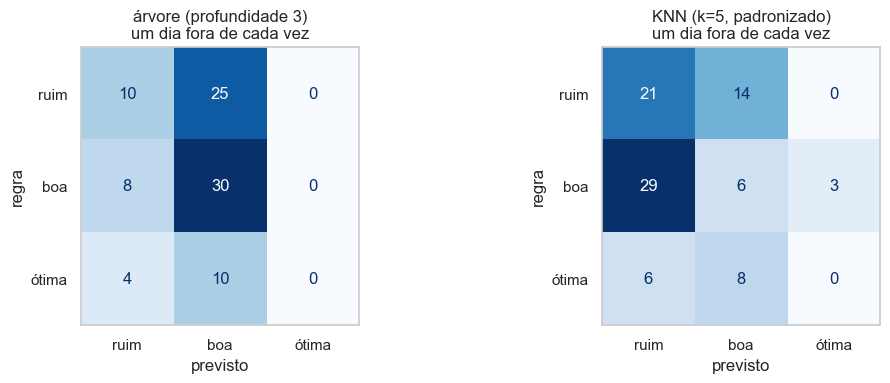

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, nome in zip(ax, list(modelos)[:2]):
    ConfusionMatrixDisplay.from_predictions(
        y, pred_cv[nome], labels=[0, 1, 2], display_labels=NOMES, ax=a, colorbar=False, cmap="Blues"
    )
    a.set(title=f"{nome}\num dia fora de cada vez", xlabel="previsto", ylabel="regra")
    a.grid(False)
plt.tight_layout()

In [12]:
aleatorio = {nome: [] for nome in list(modelos)[:2]}
for semente in range(20):
    X_a, X_b, y_a, y_b = train_test_split(X, y, test_size=0.3, stratify=y, random_state=semente)
    for nome in aleatorio:
        aleatorio[nome].append(accuracy_score(y_b, clone(modelos[nome]).fit(X_a, y_a).predict(X_b)))

pd.DataFrame({
    "sorteando linhas (média de 20 sorteios)": {n: np.mean(v) for n, v in aleatorio.items()},
    "sorteando linhas (pior e melhor)": {n: f"{min(v):.2f} a {max(v):.2f}" for n, v in aleatorio.items()},
    "um dia fora de cada vez": {n: accuracy_score(y, pred_cv[n]) for n in aleatorio},
}).round(2)

,sorteando linhas (média de 20 sorteios),sorteando linhas (pior e melhor),um dia fora de cada vez
árvore (profundidade 3),0.83,0.59 a 0.96,0.46
"KNN (k=5, padronizado)",0.54,0.41 a 0.70,0.31


**Acurácia não basta.** As classes são 40% / 44% / 16%, então a acurácia
sozinha engana. Olho também a acurácia balanceada (a média do acerto em cada
classe) e a matriz de confusão.

**O resultado é fraco, e a causa é interessante.**
- Deixando um dia de fora, a árvore acerta 0,46 e o KNN 0,31, acima do
  baseline (0,24), mas muito abaixo de "copiar a regra".
- No teste de 06–07/10 os dois ficam **abaixo do baseline** (0,08 e 0,00,
  contra 0,31). Olhando as previsões: em 06 e 07/10 aparece vento forte
  (27–30 km/h) junto de onda de 1,2–1,3 m, e a regra manda isso para `ruim`.
  Em 01–05/10 o vento forte só aparecia com onda de 1,6 m (04/10), que a regra
  classifica como `boa`, porque os 2 pontos da onda compensam. A árvore aprendeu
  "vento forte e onda acima de 1,15 m é boa" e aplicou onde a regra diz o
  contrário. **O modelo só copia a regra nas regiões que viu**, e fora delas extrapola.
- A matriz mostra o mesmo: a árvore nunca prevê `ótima` e joga 25 das 35
  horas `ruim` para `boa`.

**Um único split não é confiável.** Com 87 linhas e 7 dias, 0,08 (teste fixo)
e 0,46 (um dia fora) contam histórias bem diferentes sobre o mesmo modelo. A
validação por dia é melhor, e mesmo ela é ruidosa.

**O vazamento, medido.** Sorteando linhas, a árvore "acerta" 0,83 em média
(de 0,59 a 0,96, conforme o sorteio), contra 0,46 separando por dia. A
diferença é o ganho de ver horas vizinhas quase iguais, não de aprender o mar.

## 7. Interpretar

Um modelo que acerta e você não sabe por quê não serve para responder nada.

- Plote a árvore. Os cortes que ela encontrou parecem com os seus limiares?
- Quais features o modelo considera mais importantes? Bate com sua intuição?
- Se a acurácia veio altíssima, explique o motivo — não celebre.

|--- altura_m <= 1.40
|   |--- vento_kmh <= 20.50
|   |   |--- vento_kmh <= 15.50
|   |   |   |--- class: 2
|   |   |--- vento_kmh >  15.50
|   |   |   |--- class: 1
|   |--- vento_kmh >  20.50
|   |   |--- mare_altura_m <= 2.12
|   |   |   |--- class: 0
|   |   |--- mare_altura_m >  2.12
|   |   |   |--- class: 1
|--- altura_m >  1.40
|   |--- vento_kmh <= 25.00
|   |   |--- class: 2
|   |--- vento_kmh >  25.00
|   |   |--- class: 1



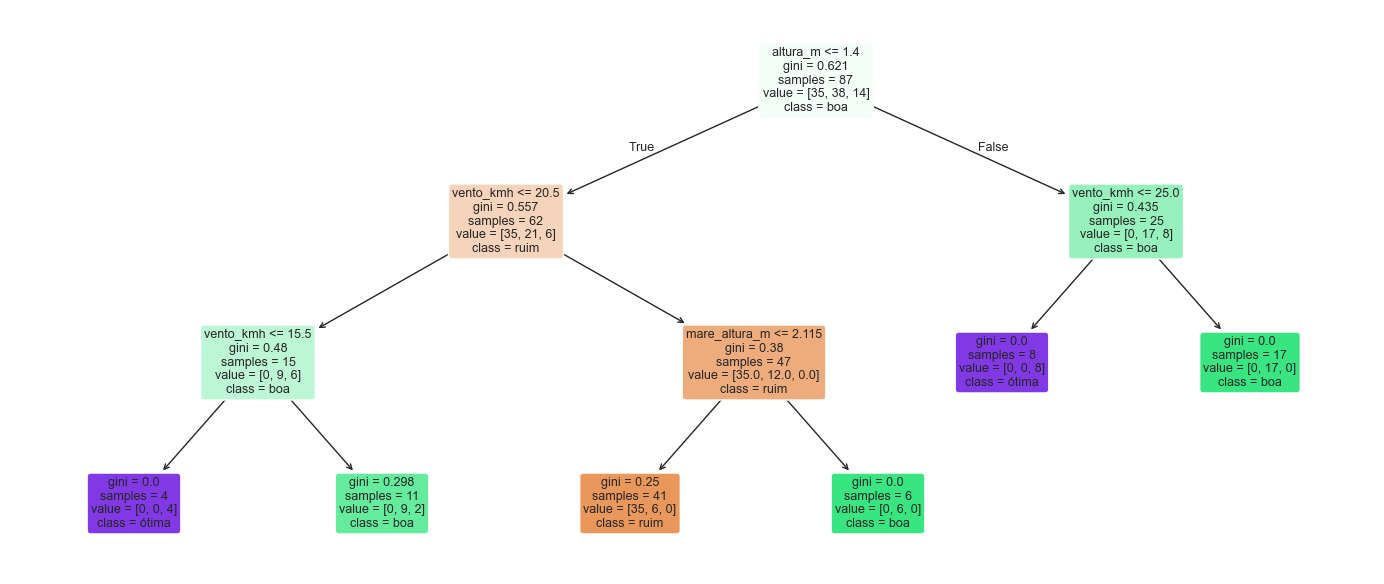

In [13]:
arvore = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(arvore, feature_names=list(X.columns), class_names=NOMES, filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout()
print(export_text(arvore, feature_names=list(X.columns)))

**Os cortes da árvore parecem com os meus limiares.** Os cortes de vento são
20,5, 15,5 e 25,0 km/h. Como o vento vem em números inteiros, "≤ 20,5"
equivale a "≤ 20", e esses são os meus limiares. O corte de onda em 1,4 m cai
no espaço vazio entre 1,3 e 1,5 m, que é onde está o meu limiar de 1,5. A
árvore **redescobriu o `if`**, como o roteiro avisa que acontece.

**Dois desvios.** O corte de 1,2 m nunca aparece: ela junta 1,1, 1,2 e 1,3 m
no mesmo lado. E aparece um corte em `mare_altura_m <= 2,115`, que não existe
na regra (próxima seção).

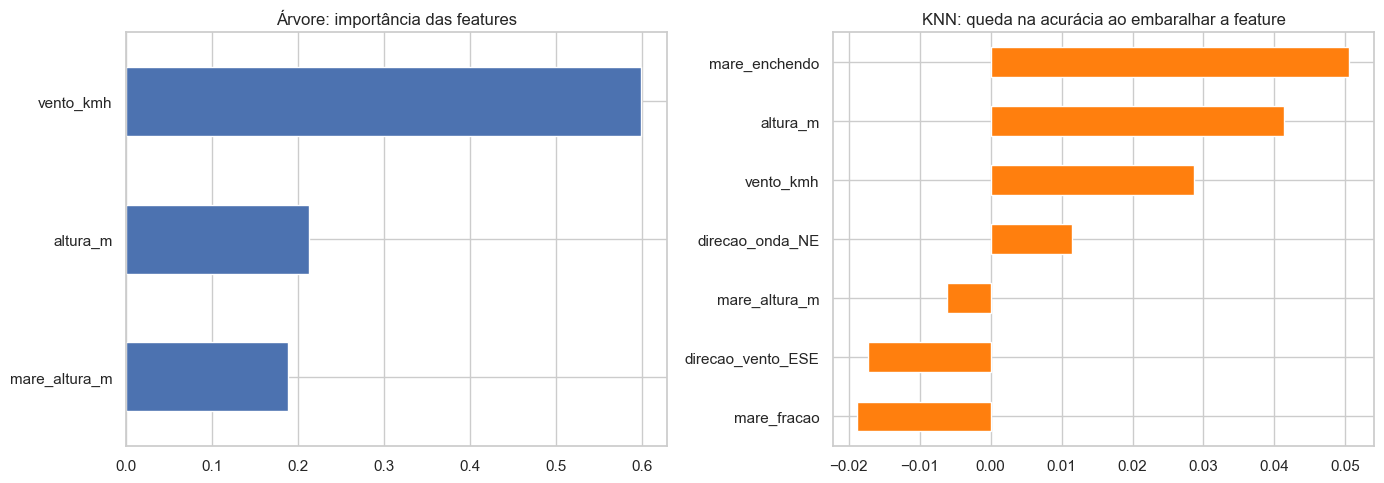

In [14]:
importancia = pd.Series(arvore.feature_importances_, index=X.columns).sort_values()
knn = clone(modelos["KNN (k=5, padronizado)"]).fit(X, y)
perm = permutation_importance(knn, X, y, n_repeats=30, random_state=0)
perm = pd.Series(perm.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
importancia[importancia > 0].plot.barh(ax=ax[0])
ax[0].set(title="Árvore: importância das features")
perm[perm.abs() > 0.005].plot.barh(ax=ax[1], color="tab:orange")
ax[1].set(title="KNN: queda na acurácia ao embaralhar a feature")
plt.tight_layout()

In [15]:
conjuntos = {
    "todas (12)": list(X.columns),
    "só altura e vento": ["altura_m", "vento_kmh"],
    "sem altura e vento": [c for c in X.columns if c not in ("altura_m", "vento_kmh")],
}
tabela = {
    nome_modelo: {
        conjunto: accuracy_score(y, cross_val_predict(clone(modelos[nome_modelo]), X[cols], y, groups=grupos, cv=logo))
        for conjunto, cols in conjuntos.items()
    }
    for nome_modelo in list(modelos)[:2]
}
tabela["baseline"] = {conjunto: accuracy_score(y, pred_cv["baseline (sempre a classe mais comum)"]) for conjunto in conjuntos}
pd.DataFrame(tabela).rename_axis("features").round(2)

,árvore (profundidade 3),"KNN (k=5, padronizado)",baseline
features,,,
todas (12),0.46,0.31,0.24
só altura e vento,0.43,0.72,0.24
sem altura e vento,0.30,0.25,0.24


In [16]:
sem_mare = [c for c in X.columns if c != "mare_altura_m"]
previsao_sem_mare = cross_val_predict(DecisionTreeClassifier(max_depth=3, random_state=0), X[sem_mare], y, groups=grupos, cv=logo)
print(f"árvore, acerto nas próprias 87 horas de treino:  {arvore.score(X, y):.2f}")
print(f"árvore sem mare_altura_m, um dia fora:           {accuracy_score(y, previsao_sem_mare):.2f}")

árvore, acerto nas próprias 87 horas de treino:  0.91
árvore sem mare_altura_m, um dia fora:           0.44


**A maré é um artefato.** A árvore deu importância 0,19 à altura da maré,
justo a variável que deixei fora da regra de propósito. Nesse ramo
(onda até 1,4 m e vento acima de 20 km/h) há 35 horas `ruim` e 12 `boa`, e o
corte isola 6 das 12 `boa`, que com a profundidade que sobrou ela não
conseguia separar só por altura e vento. A maré virou um atalho que coincide com essas
horas nestes 7 dias, sem causa nenhuma. Tirar a maré não piora o resultado
deixando um dia fora (0,44 contra 0,46), ou seja, ela só ajuda a decorar o treino.

**O KNN é pior ainda.** Na importância por permutação a feature mais
"importante" é `mare_enchendo`, o que também não faz sentido. A causa é que,
na distância, as 12 colunas pesam igual, e as 10 que não importam diluem as 2
que importam. A tabela acima confirma: com só altura e vento, o KNN sobe de
0,31 para **0,72** deixando um dia fora, o melhor resultado do notebook. As
importâncias negativas são ruído, e com 87 linhas não dá para ler muito
nelas.

**Sem altura e vento, os dois modelos ficam perto do baseline.** Era esperado:
a label foi construída só com essas duas variáveis, e nada mais no dataset a
explica.

**Por que a acurácia *não* veio 0,99.** O roteiro avisa que costuma vir, e
aqui não veio por dois motivos. Primeiro, uma árvore de profundidade 3 não
representa a soma de pontos da regra (no treino todo ela acerta 0,91, e não
1,0). Segundo, com 7 dias as combinações de onda e vento se repetem pouco,
então o modelo não vê o suficiente para copiar a regra fora do treino. Se eu
tivesse sorteado linhas, teria visto 0,83 a 0,91 e concluído que o modelo
"aprendeu". Acurácia alta só diria que ele copia a regra, e a baixa diz que 87
horas não bastam nem para isso.

## 8. Responder a pergunta

Aplique o modelo na janela inteira e produza a resposta para Felipe e Nicholas:

- Quais os melhores dias da janela de previsão?
- Em média, qual o melhor horário do dia?
- Em que grau essa resposta é uma previsão do mar, e em que grau é apenas a
  sua regra reescrita?

In [17]:
arvore_final = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)
knn_final = clone(modelos["KNN (k=5, padronizado)"]).fit(X, y)

proba = (arvore_final.predict_proba(X) + knn_final.predict_proba(X)) / 2
dados["nota_modelo"] = proba[:, 1] + 2 * proba[:, 2]
dados["classe_modelo"] = proba.argmax(axis=1)
dados["rotulo"] = dados["momento"].dt.strftime("%d/%m ") + dados["dia_semana"]

por_dia_rank = dados.groupby("rotulo").agg(
    nota_modelo=("nota_modelo", "mean"),
    horas_otimas=("classe_modelo", lambda s: int((s == 2).sum())),
    nota_regra=("nota_regra", "mean"),
).sort_values("nota_modelo", ascending=False).round(2)
por_dia_rank

,nota_modelo,horas_otimas,nota_regra
rotulo,,,
05/10 seg,1.39,8,2.62
04/10 dom,0.97,0,2.00
02/10 sex,0.96,4,2.08
01/10 qui,0.66,0,1.75
07/10 qua,0.42,0,1.54
03/10 sáb,0.37,0,1.17
06/10 ter,0.29,0,1.08


      nota_modelo  nota_regra
hora                         
17           1.02        2.29
14           0.96        2.00
16           0.92        2.00
13           0.89        1.71
15           0.85        1.86


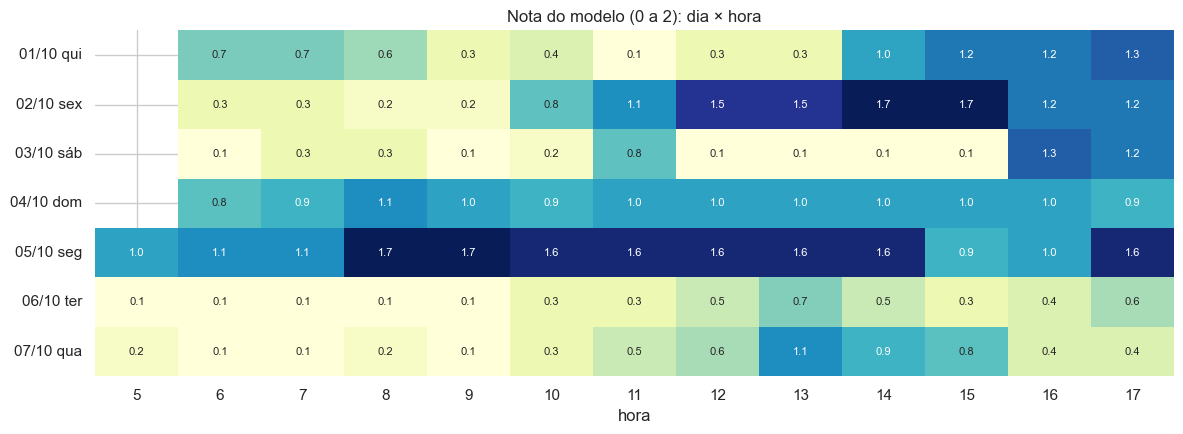

In [18]:
por_hora_rank = dados.groupby("hora").agg(nota_modelo=("nota_modelo", "mean"), nota_regra=("nota_regra", "mean")).round(2)
print(por_hora_rank.sort_values("nota_modelo", ascending=False).head(5))

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(dados.pivot_table(index="rotulo", columns="hora", values="nota_modelo"), annot=True, fmt=".1f", cmap="YlGnBu", cbar=False, ax=ax, annot_kws={"size": 8})
ax.set(title="Nota do modelo (0 a 2): dia × hora", xlabel="hora", ylabel="")
plt.tight_layout()

In [19]:
melhores = dados.sort_values(["nota_modelo", "nota_regra"], ascending=False).head(10)
melhores[["momento", "altura_m", "vento_kmh", "mare_altura_m", "nota_regra", "nota_modelo"]].round({"mare_altura_m": 2, "nota_modelo": 2}).reset_index(drop=True)

,momento,altura_m,vento_kmh,mare_altura_m,nota_regra,nota_modelo
0,2026-10-02 14:00:00,1.1,14.0,0.80,3,1.7
1,2026-10-02 15:00:00,1.1,15.0,0.91,3,1.7
2,2026-10-05 08:00:00,1.6,24.0,1.07,3,1.7
3,2026-10-05 09:00:00,1.6,23.0,1.37,3,1.7
4,2026-10-05 17:00:00,1.5,24.0,0.93,3,1.6
5,2026-10-05 10:00:00,1.5,24.0,1.67,3,1.6
6,2026-10-05 11:00:00,1.5,24.0,1.90,3,1.6
7,2026-10-05 12:00:00,1.5,24.0,2.00,3,1.6
8,2026-10-05 13:00:00,1.5,24.0,1.95,3,1.6
9,2026-10-05 14:00:00,1.5,24.0,1.76,3,1.6


**Como a nota foi feita.** A média das probabilidades da árvore e do KNN
(treinados com todos os dias), com nota = P(boa) + 2 · P(ótima), de 0 a 2.

**Melhores dias.**
- **05/10 (segunda)**, com folga: nota 1,39 e 8 das 13 horas de dia classificadas
  como `ótima`, principalmente 8–9h e 10–14h (onda de 1,5–1,6 m, vento de 23–24 km/h).
- **04/10 (domingo) e 02/10 (sexta)** empatam (0,97 e 0,96), por razões
  opostas: o domingo tem a maior onda e o vento mais forte, a sexta tem o vento
  mais fraco (13–15h) e onda pequena.
- **06/10 e 03/10** são os piores (0,29 e 0,37).

**Melhor horário.** A tarde, de 13h às 17h (notas de 0,85 a 1,02), porque o
vento cai ao longo do dia. A manhã é pior, e a EDA já tinha mostrado o vento
mais forte entre 6h e 7h. Só que a diferença entre horas (0,85 a 1,02) é
pequena perto da diferença entre dias (0,29 a 1,39): **o dia decide mais que
a hora**. E 17h é o pôr do sol (17:15), então na prática o horário é até 16h.

**Previsão do mar ou regra reescrita?** Quase só regra. O modelo ordena os
dias praticamente como a nota da regra (a única troca é 02/10 com 04/10).
Tudo o que ele sabe vem de onda e vento *previstos*, passados pela regra. E o
ranking é **dentro da amostra**: os modelos foram treinados nos mesmos dias
que estão sendo ranqueados.

## 9. Conclusão e limites

**1. A recomendação, em uma frase.** Felipe e Nicholas devem voltar na
**segunda-feira, 05/10, de manhã cedo (8–9h) ou ao meio-dia**, quando a onda de
1,5–1,6 m encontra o vento mais fraco que ela teve nesta semana.

Se o vento incomodar mais que o tamanho da onda, a alternativa é a **sexta,
02/10, à tarde (13–15h)**. Nenhuma hora é boa de verdade: o vento vem do mar
a semana inteira, e `ótima` aqui quer dizer "o melhor desta semana". E como a
label é a nossa regra, e não a opinião de surfistas, a recomendação vale tanto
quanto a regra.

**2. O teto do modelo.** Ele reproduz a minha heurística, e nem isso bem: deixando
um dia de fora, a árvore de profundidade 3 acerta 0,46, a árvore sem limite
0,69 e o KNN só com altura e vento 0,72. Nenhum chega perto de 1,0, e todos
medem a semelhança com a regra, não com o mar. O que faria da regra uma regra
melhor:
- validar os limiares com surfistas de João Pessoa, que é a parte mais frágil
  (todos os números vieram de chute informado);
- usar a **direção do vento** (terral contra maral), o fator que mais separa
  surf bom de ruim e que não variou nesta semana;
- ter o **período da onda**, que o site não publica;
- tratar a maré por pico, porque o efeito dela depende do fundo;
- pesos diferentes para onda e vento, ou uma label feita por surfistas, hora
  a hora, em vez de uma fórmula.

**3. O que a janela e o volume de linhas impedem de afirmar.**
- São 87 horas de dia em 7 dias, e horas vizinhas são quase iguais, então a
  informação independente é bem menor que 87.
- Combinações que não apareceram (onda grande com vento fraco, vento terral)
  ficam sem exemplo, e o modelo extrapola errado nelas, como se viu no teste
  de 06–07/10.
- A avaliação é instável: 0,08, 0,46 ou 0,83 para o mesmo modelo, dependendo de
  como se divide.
- Os dados são **previsão**, não medição, e a previsão perde resolução nos
  últimos dias da janela.

**4. A melhor época do ano para surfar em João Pessoa.** Não dá para responder
com estes dados. Faltaria uma série histórica de altura de onda, período e
vento, hora a hora, de pelo menos um ano (melhor três), e uma label confiável
para cada hora. Para coletar: rodar o scraper todo dia e arquivar cada
previsão (um ano de espera, e previsão não é observação), ou buscar uma
**reanálise** de ondas e vento (por exemplo a ERA5, do Copernicus) ou boias
da região. Não verifiquei se essas fontes têm resolução suficiente para a
praia de João Pessoa. A maré já tem histórico, porque a tábua é calculada.